# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Quantum Approximate Optimisation Algorithm (QAOA)

QAOA Max-Cut Analysis: 3-Node Triangle Graph

Graph Edges: [(0, 1), (1, 2), (2, 0)]
Parameters: gamma = 0.3, beta = 0.4


1. Circuit Visualisation

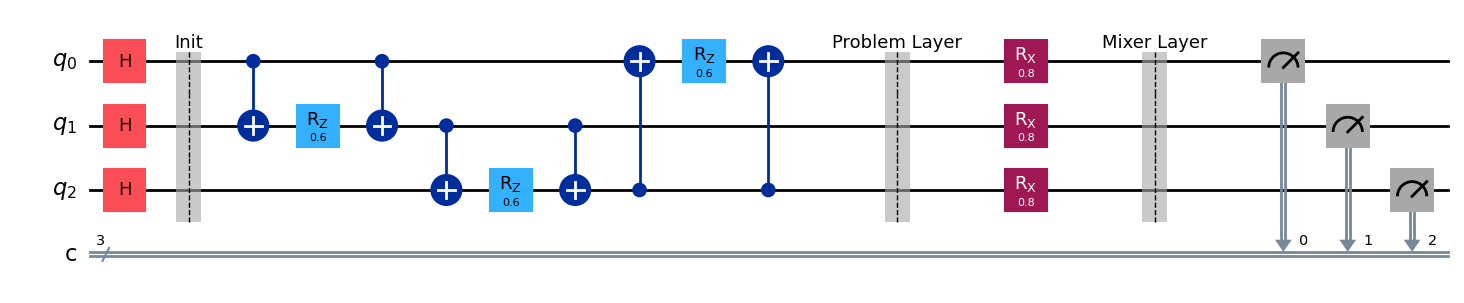

2. Unitary Evolution

The 8x8 unitary matrix describing the QAOA circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


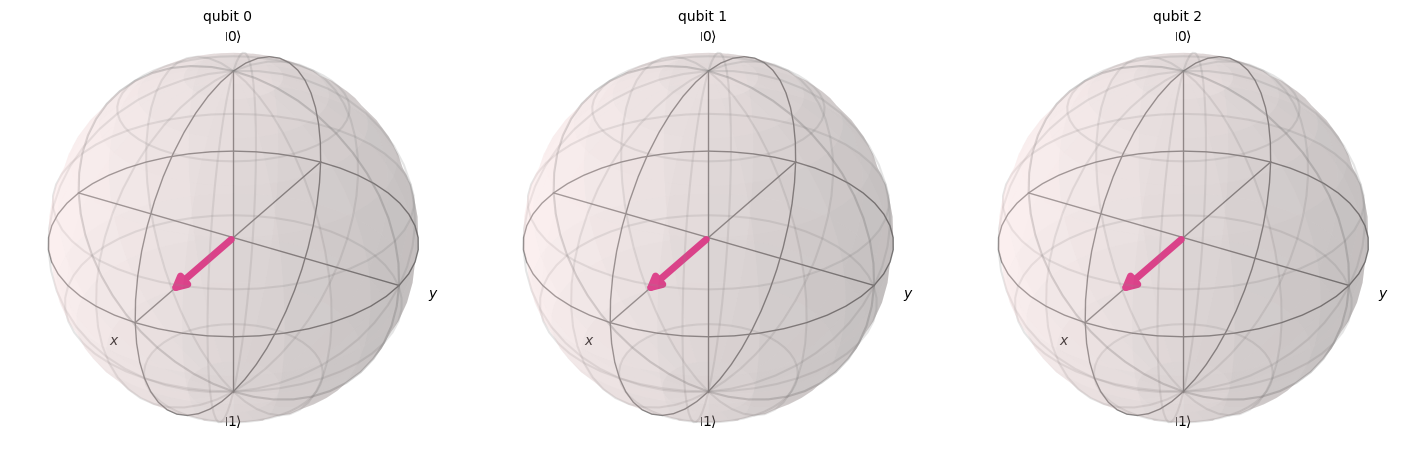


State prior to measurement (Q-Sphere):


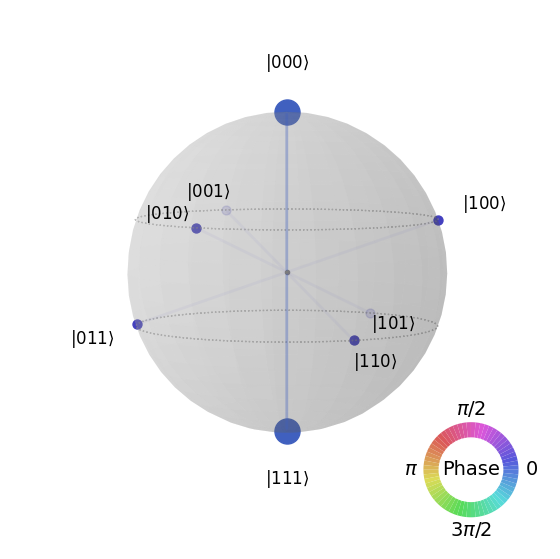

5. Measurement Analysis

Raw measurement counts: {'101': 35, '100': 49, '110': 47, '001': 42, '111': 376, '011': 53, '010': 51, '000': 371}


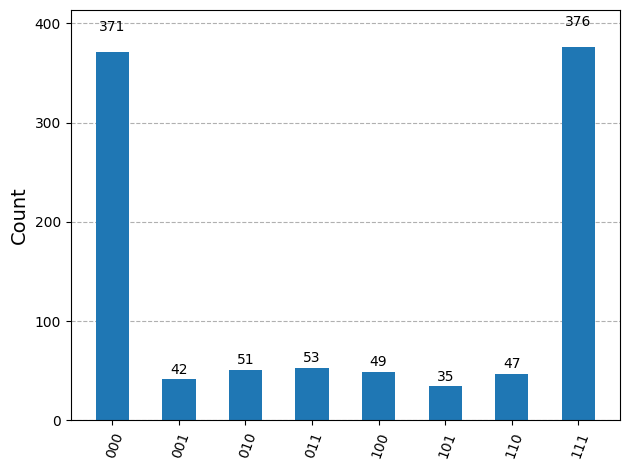

6. Verification: Max-Cut Evaluation

Evaluating cut values for each measured bitstring (partition cut size):
Bitstring |101\rangle -> Cut Size: 2 (Frequency: 35)
Bitstring |100\rangle -> Cut Size: 2 (Frequency: 49)
Bitstring |110\rangle -> Cut Size: 2 (Frequency: 47)
Bitstring |001\rangle -> Cut Size: 2 (Frequency: 42)
Bitstring |111\rangle -> Cut Size: 0 (Frequency: 376)
Bitstring |011\rangle -> Cut Size: 2 (Frequency: 53)
Bitstring |010\rangle -> Cut Size: 2 (Frequency: 51)
Bitstring |000\rangle -> Cut Size: 0 (Frequency: 371)


In [64]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION & PROBLEM DEFINITION
# ==========================================
num_nodes = 3
edges = [(0, 1), (1, 2), (2, 0)]  # 3-node triangle graph
gamma = 0.3                       # Problem angle
beta = 0.4                        # Mixer angle

# 1. Set up Registers & Circuit
qr = QuantumRegister(num_nodes, name="q")
cr = ClassicalRegister(num_nodes, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation: Equal Superposition |+>^n
qc.h(qr)
qc.barrier(label="Init")

# 3. Problem Layer (Cost Hamiltonian: U(C, gamma))
for u, v in edges:
    qc.cx(qr[u], qr[v])
    qc.rz(2 * gamma, qr[v])
    qc.cx(qr[u], qr[v])
qc.barrier(label="Problem Layer")

# 4. Mixer Layer (Transverse Field Hamiltonian: U(B, beta))
for node in range(num_nodes):
    qc.rx(2 * beta, qr[node])
qc.barrier(label="Mixer Layer")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 5. Measurement
qc.measure(qr, cr)

# 6. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"QAOA Max-Cut Analysis: {num_nodes}-Node Triangle Graph"))
print(f"Graph Edges: {edges}")
print(f"Parameters: gamma = {gamma}, beta = {beta}")

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
if num_nodes <= 3:
    print(f"The {2**num_nodes}x{2**num_nodes} unitary matrix describing the QAOA circuit:")
    display(array_to_latex(unitary.data, prefix="U_{QAOA} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {num_nodes} qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Max-Cut Verification Logic
display(Markdown("6. Verification: Max-Cut Evaluation"))
print("Evaluating cut values for each measured bitstring (partition cut size):")

def evaluate_max_cut(bitstring, graph_edges):
    cut_value = 0
    # Reverse string to match Qiskit's little-endian bit order
    rev_bit = bitstring[::-1]
    for u, v in graph_edges:
        if rev_bit[u] != rev_bit[v]:
            cut_value += 1
    return cut_value

for bitstring in counts.keys():
    c_val = evaluate_max_cut(bitstring, edges)
    print(f"Bitstring |{bitstring}\\rangle -> Cut Size: {c_val} (Frequency: {counts[bitstring]})")